# Train: Sigmoid Attention + Learned KV Gate
GPT-2 12L with sigmoid attention and per-layer KV gates. Gate from layer $\ell$ modulates attention at layer $\ell{+}1$ via additive log-gate on logits and multiplicative masking on V.

In [1]:
import os, math, time, random
from dataclasses import dataclass, asdict
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset
import matplotlib.pyplot as plt
from transformers import AutoTokenizer

from google.colab import drive
drive.mount('/content/drive')

SEED = 42
random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
    torch.backends.cudnn.deterministic = True
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device: {device}")

Mounted at /content/drive
Device: cuda


In [2]:
@dataclass
class Config:
    d_model: int = 768
    n_layer: int = 12
    n_head: int = 12
    d_ff: int = 3072
    block_size: int = 512
    vocab_size: int = 50257
    rope_base: float = 10000.0
    gate_lambda: float = 0.03

    batch_size: int = 64
    lr: float = 6e-4
    weight_decay: float = 0.01
    grad_clip: float = 1.0
    warmup_ratio: float = 0.067
    epochs: int = 3
    eval_every: int = 1000

    base_dir: str = "/content/drive/MyDrive/SigEvict"
    smoke: bool = False

    exp_name: str = "gpt2_12L_sigmoid_gated"

cfg = Config()
cfg.data_dir = os.path.join(cfg.base_dir, "data")
cfg.save_dir = os.path.join(cfg.base_dir, "models")
cfg.results_dir = os.path.join(cfg.base_dir, "results")
os.makedirs(cfg.save_dir, exist_ok=True)
os.makedirs(cfg.results_dir, exist_ok=True)

if cfg.smoke:
    cfg.epochs = 1
    cfg.eval_every = 500
# === Copy data to local for speed ===
import shutil
LOCAL_DATA = "/content/local_data"
os.makedirs(LOCAL_DATA, exist_ok=True)

for fname in ["owt_train_1B.pt", "owt_val_100K.pt"]:
    src = os.path.join(cfg.data_dir, fname)
    dst = os.path.join(LOCAL_DATA, fname)
    if not os.path.exists(dst):
        print(f"Copying {fname} to local SSD...")
        shutil.copy(src, dst)
        print(f"  Done: {os.path.getsize(dst)/1e9:.2f} GB")

cfg.data_dir = LOCAL_DATA  # Use local path
print(f"Data dir: {cfg.data_dir}")


Copying owt_train_1B.pt to local SSD...
  Done: 8.00 GB
Copying owt_val_100K.pt to local SSD...
  Done: 0.00 GB
Data dir: /content/local_data


In [3]:
tokenizer = AutoTokenizer.from_pretrained("gpt2")
train_tokens = torch.load(os.path.join(cfg.data_dir, "owt_train_1B.pt"), weights_only=True)
val_tokens = torch.load(os.path.join(cfg.data_dir, "owt_val_100K.pt"), weights_only=True)

class TokenDataset(Dataset):
    def __init__(self, tokens, block_size):
        self.tokens, self.block_size = tokens, block_size
    def __len__(self): return (len(self.tokens) - 1) // self.block_size
    def __getitem__(self, i):
        s = i * self.block_size
        return self.tokens[s:s+self.block_size], self.tokens[s+1:s+self.block_size+1]

shuffle_gen = torch.Generator()
shuffle_gen.manual_seed(SEED)
train_ds = TokenDataset(train_tokens, cfg.block_size)
val_ds = TokenDataset(val_tokens, cfg.block_size)

train_loader = DataLoader(train_ds, batch_size=cfg.batch_size, shuffle=True,
                          drop_last=True, generator=shuffle_gen, num_workers=2, pin_memory=True)
val_loader = DataLoader(val_ds, batch_size=cfg.batch_size,
                        drop_last=True, num_workers=2, pin_memory=True)

cfg.max_steps = len(train_loader) * cfg.epochs
cfg.warmup_steps = int(cfg.max_steps * cfg.warmup_ratio)
if cfg.smoke:
    cfg.max_steps = min(cfg.max_steps, 2000)
    cfg.warmup_steps = min(cfg.warmup_steps, 200)
print(f"Train: {len(train_ds):,} seqs, {len(train_loader):,} batches/epoch")
print(f"Val: {len(val_ds):,} seqs")
print(f"Max steps: {cfg.max_steps:,}, warmup: {cfg.warmup_steps:,}")


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/665 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Train: 1,953,124 seqs, 30,517 batches/epoch
Val: 195 seqs
Max steps: 91,551, warmup: 6,133


In [4]:
class RMSNorm(nn.Module):
    def __init__(self, dim, eps=1e-6):
        super().__init__()
        self.eps, self.weight = eps, nn.Parameter(torch.ones(dim))
    def forward(self, x):
        return x / torch.sqrt(x.pow(2).mean(-1, keepdim=True) + self.eps) * self.weight

class RotaryEmbedding(nn.Module):
    def __init__(self, dim, max_len=2048, base=10000.0):
        super().__init__()
        self.register_buffer("inv_freq", 1.0 / (base ** (torch.arange(0, dim, 2).float() / dim)))
    def forward(self, seq_len, device):
        t = torch.arange(seq_len, device=device).float()
        freqs = torch.outer(t, self.inv_freq)
        emb = torch.cat([freqs, freqs], dim=-1)
        return emb.cos(), emb.sin()

def apply_rope(x, cos, sin, offset=0):
    d = x.shape[-1] // 2
    T = x.shape[2]
    x1, x2 = x[..., :d], x[..., d:]
    c = cos[offset:offset+T].unsqueeze(0).unsqueeze(0)
    s = sin[offset:offset+T].unsqueeze(0).unsqueeze(0)
    return torch.cat([x1*c[...,:d] - x2*s[...,:d], x1*s[...,:d] + x2*c[...,:d]], dim=-1)

class MLP(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        self.fc = nn.Linear(cfg.d_model, cfg.d_ff, bias=False)
        self.proj = nn.Linear(cfg.d_ff, cfg.d_model, bias=False)
    def forward(self, x):
        return self.proj(F.gelu(self.fc(x)))

In [5]:
class SigmoidAttention(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        self.n_head, self.d_head = cfg.n_head, cfg.d_model // cfg.n_head
        self.scale = 1.0 / math.sqrt(self.d_head)
        self.c_attn = nn.Linear(cfg.d_model, 3 * cfg.d_model, bias=False)
        self.c_proj = nn.Linear(cfg.d_model, cfg.d_model, bias=False)
        self.q_norm, self.k_norm = RMSNorm(self.d_head), RMSNorm(self.d_head)
        self.rotary = RotaryEmbedding(self.d_head, cfg.block_size, cfg.rope_base)
        self.register_buffer("mask", torch.triu(torch.ones(cfg.block_size, cfg.block_size), diagonal=1).bool())
        self.register_buffer("pos_bias", -torch.log(torch.arange(cfg.block_size, dtype=torch.float32) + 1))

    def forward(self, x, kv_mask=None):
        B, T, C = x.shape
        q, k, v = self.c_attn(x).split(C, dim=-1)
        q = q.view(B, T, self.n_head, self.d_head).transpose(1, 2)
        k = k.view(B, T, self.n_head, self.d_head).transpose(1, 2)
        v = v.view(B, T, self.n_head, self.d_head).transpose(1, 2)
        q, k = self.q_norm(q), self.k_norm(k)
        cos, sin = self.rotary(T, x.device)
        q, k = apply_rope(q, cos, sin), apply_rope(k, cos, sin)
        logits = (q @ k.transpose(-2, -1)) * self.scale + self.pos_bias[:T].view(1, 1, T, 1)
        if kv_mask is not None:
            # Additive log-gate on logits + V mask. Mirrors the softmax-gated path.
            m = kv_mask.unsqueeze(1)
            logits = logits + torch.log(kv_mask.squeeze(-1).unsqueeze(1).unsqueeze(2).clamp(min=1e-8))
            v = v * m
        attn = torch.sigmoid(logits.masked_fill(self.mask[:T, :T], -1e9)).masked_fill(self.mask[:T, :T], 0.0)
        return self.c_proj((attn @ v).transpose(1, 2).contiguous().view(B, T, C))

    def forward_kv(self, x, kv_cache=None, kv_mask=None, start_pos=0):
        """Autoregressive forward with KV cache."""
        B, T, C = x.shape
        q, k, v = self.c_attn(x).split(C, dim=-1)
        q = q.view(B, T, self.n_head, self.d_head).transpose(1, 2)
        k = k.view(B, T, self.n_head, self.d_head).transpose(1, 2)
        v = v.view(B, T, self.n_head, self.d_head).transpose(1, 2)
        q, k = self.q_norm(q), self.k_norm(k)
        cos, sin = self.rotary(start_pos + T, x.device)
        q = apply_rope(q, cos, sin, offset=start_pos)
        k = apply_rope(k, cos, sin, offset=start_pos)
        if kv_cache is not None:
            k = torch.cat([kv_cache[0], k], dim=2)
            v = torch.cat([kv_cache[1], v], dim=2)
        T_full = k.size(2)
        logits = (q @ k.transpose(-2, -1)) * self.scale
        # Absolute query position (eviction-invariant).
        if T == 1:
            logits = logits + (-math.log(start_pos + 1))
        else:
            logits = logits + self.pos_bias[:T].view(1, 1, T, 1)
        if kv_mask is not None:
            m = kv_mask.unsqueeze(1)
            logits = logits + torch.log(kv_mask.squeeze(-1).unsqueeze(1).unsqueeze(2).clamp(min=1e-8))
            v_att = v * m
        else:
            v_att = v
        causal = self.mask[start_pos:start_pos+T, :T_full]
        attn = torch.sigmoid(logits.masked_fill(causal.unsqueeze(0).unsqueeze(0), -1e9))
        attn = attn.masked_fill(causal.unsqueeze(0).unsqueeze(0), 0.0)
        y = (attn @ v_att).transpose(1, 2).contiguous().view(B, T, C)
        return self.c_proj(y), (k, v)   # cache raw KV

class GatedBlock(nn.Module):
    def __init__(self, cfg, layer_idx):
        super().__init__()
        self.ln1, self.attn = nn.LayerNorm(cfg.d_model), SigmoidAttention(cfg)
        self.ln2, self.mlp = nn.LayerNorm(cfg.d_model), MLP(cfg)
        self.has_gate = layer_idx < cfg.n_layer - 1
        if self.has_gate:
            # Isolate gate init RNG so shared-param init matches the no-gate variant.
            cpu_state = torch.random.get_rng_state()
            gpu_state = torch.cuda.get_rng_state() if torch.cuda.is_available() else None
            self.gate = nn.Linear(cfg.d_model, 1, bias=True)
            self.gate._skip_base_init = True
            torch.random.set_rng_state(cpu_state)
            if gpu_state is not None:
                torch.cuda.set_rng_state(gpu_state)

    def forward(self, x, kv_mask=None):
        x = x + self.attn(self.ln1(x), kv_mask=kv_mask)
        x = x + self.mlp(self.ln2(x))
        g = torch.sigmoid(self.gate(x)) if self.has_gate else None
        return x, g

    def forward_kv(self, x, kv_cache=None, kv_mask=None, start_pos=0):
        attn_out, new_kv = self.attn.forward_kv(self.ln1(x), kv_cache=kv_cache,
                                                  kv_mask=kv_mask, start_pos=start_pos)
        x = x + attn_out
        x = x + self.mlp(self.ln2(x))
        g = torch.sigmoid(self.gate(x)) if self.has_gate else None
        return x, new_kv, g

class GPT2SigmoidGated(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        self.cfg = cfg
        self.wte = nn.Embedding(cfg.vocab_size, cfg.d_model)
        self.blocks = nn.ModuleList([GatedBlock(cfg, i) for i in range(cfg.n_layer)])
        self.ln_f = nn.LayerNorm(cfg.d_model)
        self.head = nn.Linear(cfg.d_model, cfg.vocab_size, bias=False)
        self.wte.weight = self.head.weight
        self.apply(self._init)
        for block in self.blocks:
            if block.has_gate:
                nn.init.zeros_(block.gate.weight)
                nn.init.constant_(block.gate.bias, 5.0)

    def _init(self, m):
        if hasattr(m, '_skip_base_init'): return
        if isinstance(m, nn.Linear): nn.init.normal_(m.weight, std=0.02)
        elif isinstance(m, nn.Embedding): nn.init.normal_(m.weight, std=0.02)

    def forward(self, idx, targets=None):
        x, gates = self.wte(idx), []
        kv_mask = None
        for block in self.blocks:
            x, g = block(x, kv_mask=kv_mask)
            if g is not None: gates.append(g)
            kv_mask = g
        logits = self.head(self.ln_f(x))
        loss = F.cross_entropy(logits.view(-1, logits.size(-1)), targets.view(-1)) if targets is not None else None
        budget = sum(g.mean() for g in gates) / len(gates) if gates else None
        return logits, loss, budget, gates

    def prefill(self, idx):
        """Returns (logits, caches, cache_masks)."""
        B, T = idx.shape
        x = self.wte(idx)
        caches, cache_masks = [], []
        prev_mask = torch.ones(B, T, 1, device=idx.device)
        for block in self.blocks:
            x, kv, gate = block.forward_kv(x, kv_cache=None, kv_mask=prev_mask, start_pos=0)
            caches.append(kv)
            cache_masks.append(prev_mask)
            prev_mask = gate if gate is not None else torch.ones(B, T, 1, device=idx.device)
        logits = self.head(self.ln_f(x))
        return logits, caches, cache_masks

    def decode_step(self, tok, pos, caches, cache_masks):
        """Single-token decode. Returns (logits, new_caches, new_cache_masks)."""
        B = tok.size(0)
        x = self.wte(tok)
        new_caches, new_cache_masks = [], []
        prev_gate_new = torch.ones(B, 1, 1, device=tok.device)
        for l, block in enumerate(self.blocks):
            kv_mask = torch.cat([cache_masks[l], prev_gate_new], dim=1)
            x, kv, gate = block.forward_kv(x, kv_cache=caches[l], kv_mask=kv_mask, start_pos=pos)
            new_caches.append(kv)
            new_cache_masks.append(kv_mask)
            prev_gate_new = gate if gate is not None else torch.ones(B, 1, 1, device=tok.device)
        logits = self.head(self.ln_f(x)).squeeze(1)
        return logits, new_caches, new_cache_masks

In [6]:
torch.manual_seed(SEED)
if torch.cuda.is_available(): torch.cuda.manual_seed_all(SEED)
model = GPT2SigmoidGated(cfg).to(device)
n_params = sum(p.numel() for p in model.parameters())
gate_params = sum(p.numel() for b in model.blocks if b.has_gate for p in b.gate.parameters())
print(f"Parameters: {n_params:,} (gate: {gate_params:,}, {gate_params/n_params*100:.3f}%)")
print(f"Gate init: sigmoid(5.0) = {torch.sigmoid(torch.tensor(5.0)).item():.3f}")

Parameters: 123,580,427 (gate: 8,459, 0.007%)
Gate init: sigmoid(5.0) = 0.993


In [7]:
optimizer = torch.optim.AdamW(model.parameters(), lr=cfg.lr, weight_decay=cfg.weight_decay)
scaler = torch.amp.GradScaler('cuda')

def get_lr(step):
    if step < cfg.warmup_steps: return cfg.lr * step / cfg.warmup_steps
    return cfg.lr * 0.5 * (1 + math.cos(math.pi * (step - cfg.warmup_steps) / (cfg.max_steps - cfg.warmup_steps)))

@torch.no_grad()
def evaluate():
    model.eval()
    losses, budgets = [], []
    for i, (x, y) in enumerate(val_loader):
        if i >= 50: break
        x, y = x.to(device), y.to(device)
        with torch.amp.autocast('cuda', dtype=torch.bfloat16):
            _, loss, budget, _ = model(x, y)
        losses.append(loss.item())
        budgets.append(budget.item())
    model.train()
    avg_loss = sum(losses) / len(losses)
    return {"loss": avg_loss, "ppl": math.exp(min(avg_loss, 20.0)), "budget": sum(budgets)/len(budgets)}


In [ ]:
from tqdm.auto import tqdm

history = {"step": [], "train_loss": [], "val_loss": [], "val_ppl": [], "budget": [], "gate_means": []}
step, running_loss, running_budget = 0, 0, 0
t0 = time.time()

model.train()
pbar = tqdm(total=cfg.max_steps, desc="Training", unit="step")

for epoch in range(cfg.epochs):
    if step >= cfg.max_steps: break
    for x, y in train_loader:
        x, y = x.to(device), y.to(device)
        for pg in optimizer.param_groups: pg['lr'] = get_lr(step)

        with torch.amp.autocast('cuda', dtype=torch.bfloat16):
            _, loss, budget, gates = model(x, y)
            total_loss = loss + cfg.gate_lambda * budget

        optimizer.zero_grad()
        scaler.scale(total_loss).backward()
        scaler.unscale_(optimizer)
        nn.utils.clip_grad_norm_(model.parameters(), cfg.grad_clip)
        scaler.step(optimizer)
        scaler.update()

        running_loss += loss.item()
        running_budget += budget.item()
        step += 1
        pbar.update(1)
        pbar.set_postfix(loss=f"{loss.item():.3f}", gate=f"{budget.item():.3f}", lr=f"{get_lr(step):.1e}")

        if step >= cfg.max_steps: break

        if step % cfg.eval_every == 0:
            ev = evaluate()
            history["step"].append(step)
            history["train_loss"].append(running_loss / cfg.eval_every)
            history["val_loss"].append(ev["loss"])
            history["val_ppl"].append(ev["ppl"])
            history["budget"].append(running_budget / cfg.eval_every)
            history["gate_means"].append([g.mean().item() for g in gates])
            pbar.write(f"Step {step:>6} | Train {running_loss/cfg.eval_every:.4f} | "
                       f"Val {ev['loss']:.4f} PPL {ev['ppl']:.1f} | "
                       f"Gate {running_budget/cfg.eval_every:.3f} | {(time.time()-t0)/60:.1f}m")
            running_loss, running_budget = 0, 0

pbar.close()
train_time = time.time() - t0
final_ev = evaluate()
print(f"\nDone in {train_time/60:.1f}m | Final: val_loss={final_ev['loss']:.4f} PPL={final_ev['ppl']:.1f}")


Training:   0%|          | 0/91551 [00:00<?, ?step/s]

Step   1000 | Train 6.9555 | Val 5.9166 PPL 371.1 | Gate 0.604 | 8.7m
Step   2000 | Train 5.3576 | Val 5.1709 PPL 176.1 | Gate 0.434 | 17.5m
Step   3000 | Train 4.7547 | Val 4.6532 PPL 104.9 | Gate 0.409 | 26.2m
Step   4000 | Train 4.3766 | Val 4.3708 PPL 79.1 | Gate 0.402 | 34.9m
Step   5000 | Train 4.1690 | Val 4.1944 PPL 66.3 | Gate 0.400 | 43.7m
Step   6000 | Train 4.0518 | Val 4.0949 PPL 60.0 | Gate 0.408 | 52.4m
Step   7000 | Train 3.9607 | Val 4.0008 PPL 54.6 | Gate 0.418 | 61.1m
Step   8000 | Train 3.8722 | Val 3.9232 PPL 50.6 | Gate 0.419 | 69.8m
Step   9000 | Train 3.8085 | Val 3.8622 PPL 47.6 | Gate 0.421 | 78.6m
Step  10000 | Train 3.7573 | Val 3.8073 PPL 45.0 | Gate 0.419 | 87.3m
Step  11000 | Train 3.7173 | Val 3.7754 PPL 43.6 | Gate 0.418 | 96.0m
Step  12000 | Train 3.6781 | Val 3.7385 PPL 42.0 | Gate 0.418 | 104.8m
Step  13000 | Train 3.6480 | Val 3.7028 PPL 40.6 | Gate 0.416 | 113.5m
Step  14000 | Train 3.6246 | Val 3.6802 PPL 39.7 | Gate 0.414 | 122.2m
Step  15000 | T

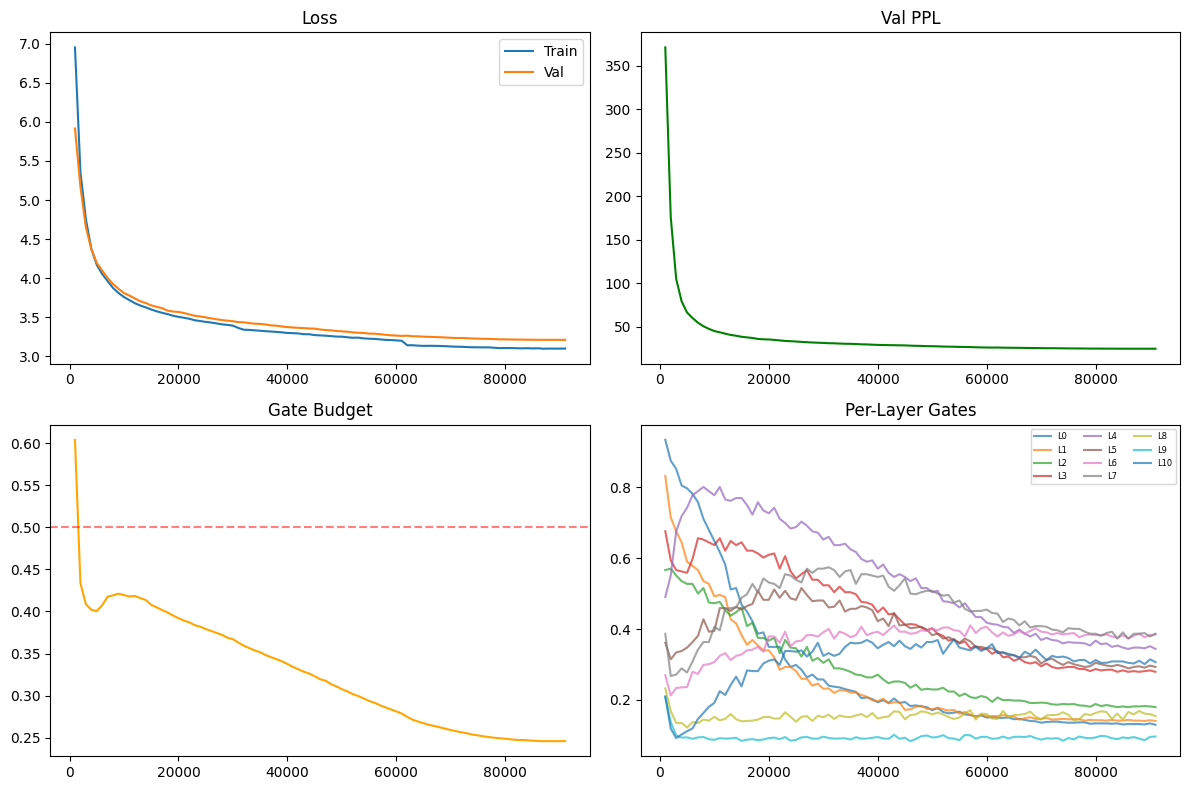

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes[0,0].plot(history["step"], history["train_loss"], label="Train")
axes[0,0].plot(history["step"], history["val_loss"], label="Val"); axes[0,0].legend(); axes[0,0].set_title("Loss")
axes[0,1].plot(history["step"], history["val_ppl"], color="green"); axes[0,1].set_title("Val PPL")
axes[1,0].plot(history["step"], history["budget"], color="orange"); axes[1,0].axhline(0.5, ls='--', color='red', alpha=0.5); axes[1,0].set_title("Gate Budget")
gate_arr = torch.tensor(history["gate_means"])
for i in range(gate_arr.shape[1]): axes[1,1].plot(history["step"], gate_arr[:,i], alpha=0.7, label=f"L{i}")
axes[1,1].legend(fontsize=6, ncol=3); axes[1,1].set_title("Per-Layer Gates")
plt.tight_layout(); plt.savefig(os.path.join(cfg.results_dir, f"{cfg.exp_name}_curves.png"), dpi=150); plt.show()

In [ ]:

DEMO_PROMPT = "I am the last human alive. Suddenly, someone knocked my door."

@torch.no_grad()
def extract_attention_and_gates(model, input_ids):
    """Forward pass extracting per-layer attention maps and gate values."""
    B, T = input_ids.shape
    x = model.wte(input_ids)
    C = x.shape[-1]

    attn_maps, gate_vals = [], []
    kv_mask = None

    for block in model.blocks:
        attn_mod = block.attn
        h = block.ln1(x)
        q, k, v = attn_mod.c_attn(h).split(C, dim=-1)
        q = q.view(B, T, attn_mod.n_head, attn_mod.d_head).transpose(1, 2)
        k = k.view(B, T, attn_mod.n_head, attn_mod.d_head).transpose(1, 2)
        v = v.view(B, T, attn_mod.n_head, attn_mod.d_head).transpose(1, 2)
        q, k = attn_mod.q_norm(q), attn_mod.k_norm(k)
        cos, sin = attn_mod.rotary(T, x.device)
        q, k = apply_rope(q, cos, sin), apply_rope(k, cos, sin)

        if hasattr(attn_mod, 'pos_bias'):
            # Sigmoid attention (mirrors training forward).
            logits = (q @ k.transpose(-2, -1)) * attn_mod.scale
            logits = logits + attn_mod.pos_bias[:T].view(1, 1, T, 1)
            if kv_mask is not None:
                logits = logits + torch.log(kv_mask.squeeze(-1).unsqueeze(1).unsqueeze(2).clamp(min=1e-8))
            logits = logits.masked_fill(attn_mod.mask[:T, :T], -1e9)
            weights = torch.sigmoid(logits).masked_fill(attn_mod.mask[:T, :T], 0.0)
        else:
            # Softmax attention
            logits = (q @ k.transpose(-2, -1)) * attn_mod.scale
            logits = logits.masked_fill(attn_mod.mask[:T, :T], float('-inf'))
            if kv_mask is not None:
                logits = logits + torch.log(kv_mask.squeeze(-1).unsqueeze(1).unsqueeze(2).clamp(min=1e-8))
            weights = F.softmax(logits, dim=-1)

        attn_maps.append(weights.float().cpu())

        if hasattr(block, 'has_gate'):
            x, g = block(x, kv_mask=kv_mask)
            if g is not None:
                gate_vals.append(g.squeeze(-1).float().cpu())
            kv_mask = g
        else:
            x = block(x)

    return attn_maps, gate_vals

Prompt: I am the last human alive. Suddenly, someone knocked my door.
I am the last human alive. Suddenly, someone knocked my door. He was dead. He was in a wheelchair."

The victim suffered from a broken leg, which could have been caused by the time the injury occurred. The coroner said she had not yet examined the body.

The woman told a court she had seen her son "piss out" and felt like her "first shot".

She was a passenger in the plane, in a wheelchair, from London to Chicago in 2001.

The body had been moved to hospital by a


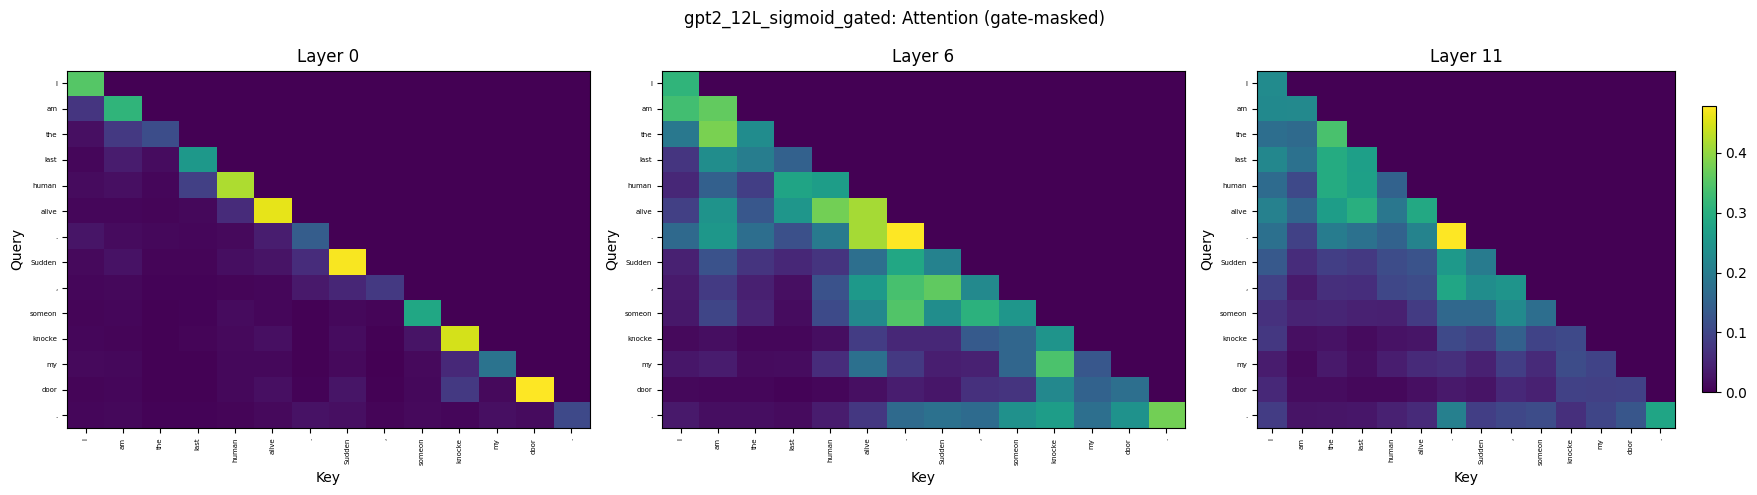

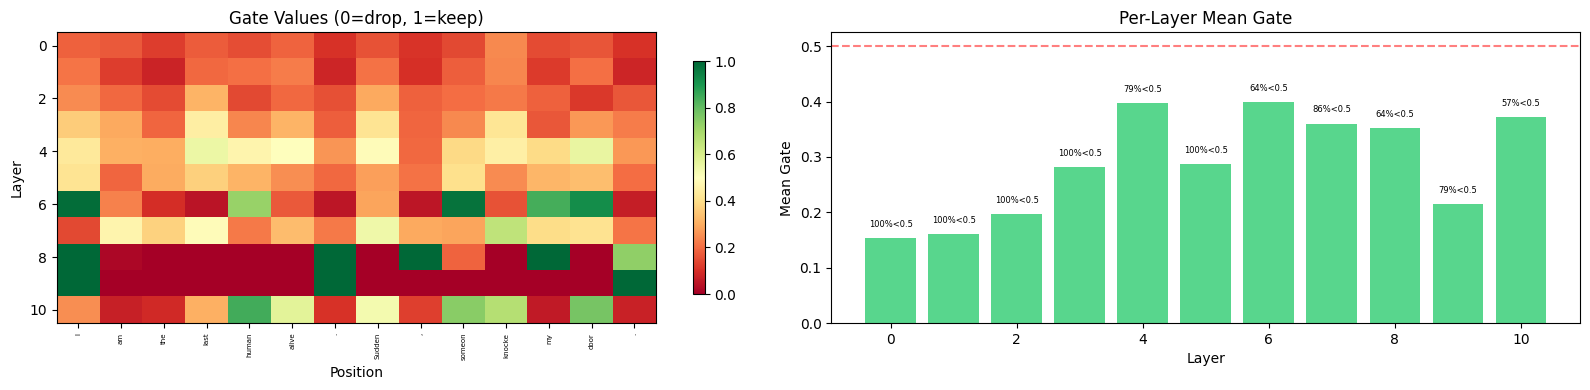

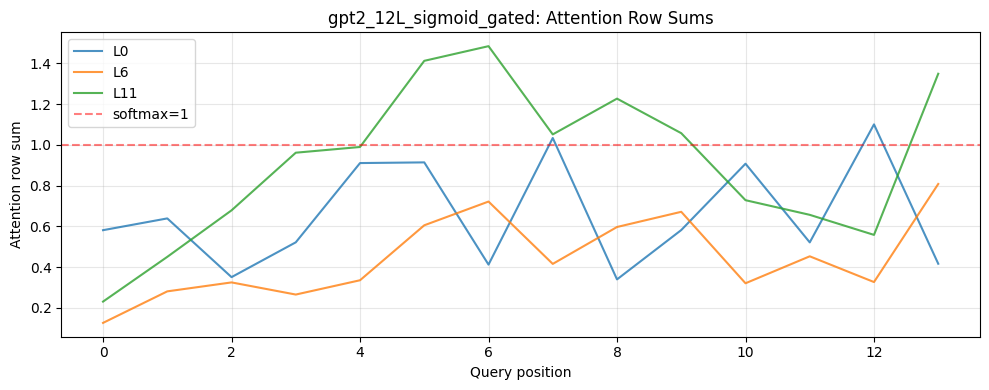

In [ ]:

@torch.no_grad()
def generate(prompt, max_tokens=100, temp=0.8, top_k=50):
    model.eval()
    tokens = tokenizer.encode(prompt, return_tensors="pt").to(device)
    for _ in range(max_tokens):
        if tokens.shape[1] >= cfg.block_size: break
        with torch.amp.autocast('cuda', dtype=torch.bfloat16):
            logits = model(tokens)[0][:, -1, :] / temp
        v, _ = torch.topk(logits, min(top_k, logits.size(-1)))
        logits[logits < v[:, [-1]]] = float('-inf')
        tokens = torch.cat([tokens, torch.multinomial(F.softmax(logits, -1), 1)], 1)
    return tokenizer.decode(tokens[0])

print("=" * 60)
print(f"Prompt: {DEMO_PROMPT}")
print("=" * 60)
print(generate(DEMO_PROMPT))
print("=" * 60)


model.eval()
tokens = tokenizer(DEMO_PROMPT, return_tensors="pt").input_ids.to(device)
attn_maps, gate_vals = extract_attention_and_gates(model, tokens)
T = tokens.shape[1]
tok_labels = [tokenizer.decode([tokens[0, i].item()]).strip()[:6] for i in range(T)]

# Attention heatmaps
layers_to_show = [0, cfg.n_layer // 2, cfg.n_layer - 1]
fig, axes = plt.subplots(1, len(layers_to_show), figsize=(6 * len(layers_to_show), 5))
for ax, li in zip(axes, layers_to_show):
    A = attn_maps[li][0].mean(0).numpy()
    im = ax.imshow(A, aspect='auto', cmap='viridis')
    ax.set_title(f"Layer {li}")
    ax.set_xlabel("Key"); ax.set_ylabel("Query")
    if T <= 40:
        ax.set_xticks(range(T)); ax.set_xticklabels(tok_labels, rotation=90, fontsize=5)
        ax.set_yticks(range(T)); ax.set_yticklabels(tok_labels, fontsize=5)
plt.colorbar(im, ax=axes[-1], shrink=0.8)
plt.suptitle(f"{cfg.exp_name}: Attention (gate-masked)", fontsize=12)
plt.tight_layout()
plt.savefig(os.path.join(cfg.results_dir, f"{cfg.exp_name}_attn_demo.png"), dpi=150)
plt.show()

# Gate heatmap (layer x position)
gate_matrix = torch.stack([g[0] for g in gate_vals], dim=0).numpy()
fig, axes = plt.subplots(1, 2, figsize=(16, 4))
im = axes[0].imshow(gate_matrix, aspect='auto', cmap='RdYlGn', vmin=0, vmax=1)
axes[0].set_xlabel("Position"); axes[0].set_ylabel("Layer")
axes[0].set_title("Gate Values (0=drop, 1=keep)")
if T <= 40:
    axes[0].set_xticks(range(T))
    axes[0].set_xticklabels(tok_labels, rotation=90, fontsize=5)
plt.colorbar(im, ax=axes[0], shrink=0.8)

# Per-layer gate statistics
means = gate_matrix.mean(axis=1)
below_half = (gate_matrix < 0.5).mean(axis=1) * 100
x_pos = range(len(means))
axes[1].bar(x_pos, means, color='#2ecc71', alpha=0.8)
axes[1].axhline(0.5, color='red', ls='--', alpha=0.5)
axes[1].set_xlabel("Layer"); axes[1].set_ylabel("Mean Gate")
axes[1].set_title("Per-Layer Mean Gate")
for i, (m, b) in enumerate(zip(means, below_half)):
    axes[1].text(i, m + 0.02, f"{b:.0f}%<0.5", ha='center', fontsize=6)
plt.tight_layout()
plt.savefig(os.path.join(cfg.results_dir, f"{cfg.exp_name}_gate_demo.png"), dpi=150)
plt.show()

# Attention row sums
fig, ax = plt.subplots(figsize=(10, 4))
for li in layers_to_show:
    row_sums = attn_maps[li][0].mean(0).sum(-1).numpy()
    ax.plot(row_sums, label=f"L{li}", alpha=0.8)
ax.axhline(1.0, color='red', ls='--', alpha=0.5, label="softmax=1")
ax.set_xlabel("Query position"); ax.set_ylabel("Attention row sum")
ax.set_title(f"{cfg.exp_name}: Attention Row Sums")
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(cfg.results_dir, f"{cfg.exp_name}_rowsums.png"), dpi=150)
plt.show()

In [ ]:
def physical_prune(caches, cache_masks, tau):
    """Remove KV entries with gate value below threshold tau."""
    new_caches, new_masks = [], []
    for l in range(len(caches)):
        k, v = caches[l]
        mask = cache_masks[l]
        keep = (mask.squeeze(-1) >= tau)
        keep_idx = keep[0].nonzero(as_tuple=True)[0]
        if len(keep_idx) == 0:
            keep_idx = torch.tensor([mask.size(1) - 1], device=mask.device)
        new_caches.append((k[:, :, keep_idx, :], v[:, :, keep_idx, :]))
        new_masks.append(mask[:, keep_idx, :])
    return new_caches, new_masks

def prune_new_token(caches, cache_masks, tau):
    """Prune the newly appended token if its gate value < tau."""
    new_caches, new_masks = [], []
    for l in range(len(caches)):
        k, v = caches[l]
        mask = cache_masks[l]
        if (mask[:, -1:, :] < tau).all():
            new_caches.append((k[:, :, :-1, :], v[:, :, :-1, :]))
            new_masks.append(mask[:, :-1, :])
        else:
            new_caches.append((k, v))
            new_masks.append(mask)
    return new_caches, new_masks

In [ ]:

@torch.no_grad()
def eval_physical_prune(tau, n_seqs=5 if cfg.smoke else 30):
    """Evaluate decode PPL and cache compression under eviction at threshold tau."""
    model.eval()
    PREFILL, DECODE = 256, 128
    n_layer = cfg.n_layer
    losses, final_entries = [], []
    for si in range(n_seqs):
        start = si * (PREFILL + DECODE)
        if start + PREFILL + DECODE > len(val_tokens):
            break
        tokens = val_tokens[start:start + PREFILL + DECODE].unsqueeze(0).to(device)
        prefix, suffix = tokens[:, :PREFILL], tokens[:, PREFILL:]

        with torch.amp.autocast('cuda', dtype=torch.bfloat16):
            prefill_logits, caches, cache_masks = model.prefill(prefix)
            if tau > 0:
                caches, cache_masks = physical_prune(caches, cache_masks, tau)

            seq_losses = [F.cross_entropy(prefill_logits[:, -1, :], suffix[:, 0]).item()]
            for t in range(DECODE - 1):
                logits, caches, cache_masks = model.decode_step(
                    suffix[:, t:t+1], PREFILL + t, caches, cache_masks)
                if tau > 0:
                    caches, cache_masks = prune_new_token(caches, cache_masks, tau)
                seq_losses.append(F.cross_entropy(logits, suffix[:, t+1]).item())

        losses.append(sum(seq_losses) / len(seq_losses))
        final_entries.append(sum(c[0].size(2) for c in caches))

    avg_loss = sum(losses) / len(losses)
    avg_entries = sum(final_entries) / len(final_entries)
    return avg_loss, math.exp(min(avg_loss, 20.0)), avg_entries

# Verify prefill-forward consistency
model.eval()
with torch.no_grad():
    test_x = torch.randint(0, cfg.vocab_size, (1, 64), device=device)
    logits_fwd, _, _, _ = model(test_x)
    logits_pf, _, _ = model.prefill(test_x)
    diff = (logits_fwd - logits_pf).abs().max().item()
    print(f"forward vs prefill max diff: {diff:.6f} ({'OK' if diff < 1e-2 else 'MISMATCH'})")

thresholds = [0.0, 0.01, 0.02, 0.05, 0.1, 0.15, 0.2, 0.25, 0.3, 0.35, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]
sweep_results = []

print(f"\n{'tau':>6} {'Loss':>8} {'PPL':>8} {'Compress%':>10} {'delta_PPL':>10}")
print("-" * 50)
for tau in thresholds:
    loss, ppl, entries = eval_physical_prune(tau)
    sweep_results.append({"tau": tau, "loss": loss, "ppl": ppl, "entries": entries})
    if len(sweep_results) > 1:
        compression = (1 - entries / sweep_results[0]["entries"]) * 100
    else:
        compression = 0.0
    sweep_results[-1]["compression"] = compression
    delta = ppl - sweep_results[0]["ppl"]
    print(f"{tau:>6.2f} {loss:>8.4f} {ppl:>8.1f} {compression:>9.1f}% {delta:>+9.2f}")

# Best tau: maximum compression where delta PPL < 0.5
baseline_ppl = sweep_results[0]["ppl"]
candidates = [r for r in sweep_results if r["ppl"] - baseline_ppl < 0.5]
best = max(candidates, key=lambda r: r["compression"])
print(f"\nBest (max compress, delta PPL < 0.5): tau={best['tau']:.2f}, "
      f"PPL={best['ppl']:.1f} (delta={best['ppl']-baseline_ppl:+.2f}), "
      f"compress={best['compression']:.1f}%")

# Sweep curve
fig, ax1 = plt.subplots(figsize=(10, 5))
taus = [r["tau"] for r in sweep_results]
ppls = [r["ppl"] for r in sweep_results]
comps = [r["compression"] for r in sweep_results]
ax1.plot(taus, ppls, 'o-', color='#e74c3c', label='PPL')
ax1.axhline(baseline_ppl + 0.5, color='#e74c3c', ls='--', alpha=0.4, label='PPL + 0.5')
ax1.axvline(best["tau"], color='gray', ls=':', alpha=0.6)
ax1.set_xlabel("Threshold tau"); ax1.set_ylabel("PPL", color='#e74c3c')
ax2 = ax1.twinx()
ax2.plot(taus, comps, 's-', color='#2ecc71', label='Compression %')
ax2.set_ylabel("Compression %", color='#2ecc71')
ax1.legend(loc='upper left'); ax2.legend(loc='upper right')
ax1.set_title(f"{cfg.exp_name}: PPL-Compression Tradeoff")
ax1.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(cfg.results_dir, f"{cfg.exp_name}_sweep.png"), dpi=150)
plt.show()

In [ ]:

torch.save({"model_state_dict": model.state_dict(), "config": asdict(cfg),
            "history": history, "n_params": n_params, "train_time_sec": train_time,
            "final_eval": {"loss": final_ev["loss"], "ppl": final_ev["ppl"]},
            "best_tau": best["tau"], "sweep_results": sweep_results},
           os.path.join(cfg.save_dir, f"{cfg.exp_name}.pt"))
print(f"Saved to {cfg.save_dir}/{cfg.exp_name}.pt (best_tau={best['tau']:.2f})")